In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

orders = pd.read_csv("./data/orders.csv")
communication_logs = pd.read_csv("./data/communication_logs.csv")
supply_chain =pd.read_csv("./data/supply_chain.csv")
support_tickets =pd.read_csv("./data/support_tickets.csv")
vet_calls = pd.read_csv("./data/vet_calls.csv")

In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                10000 non-null  object 
 1   customer_id             10000 non-null  int64  
 2   order_date              10000 non-null  object 
 3   order_status            10000 non-null  object 
 4   payment_mode            10000 non-null  object 
 5   product_id              10000 non-null  object 
 6   product_category        10000 non-null  object 
 7   order_value             10000 non-null  float64
 8   discount_value          10000 non-null  float64
 9   promised_delivery_date  10000 non-null  object 
 10  actual_delivery_date    10000 non-null  object 
 11  city                    10000 non-null  object 
 12  state                   10000 non-null  object 
 13  is_repeat_customer      10000 non-null  bool   
 14  shipment_partner        10000 non-null 

In [5]:
orders.head()

,order_id,customer_id,order_date,order_status,payment_mode,product_id,product_category,order_value,discount_value,promised_delivery_date,actual_delivery_date,city,state,is_repeat_customer,shipment_partner,shipment_mode
0,ST2025000000,8270,2024-02-10 02:13:00,Delivered,UPI,SKU03899,Accessories,2384.14,298.90,2024-02-15 02:13:00,2024-02-14 02:13:00,Kolkata,Tamil Nadu,True,Bluedart,Surface
1,ST2025000001,1860,2024-09-09 22:45:00,Shipped,COD,SKU03852,Food,2449.95,462.15,2024-09-13 22:45:00,2024-09-14 22:45:00,Delhi,Tamil Nadu,True,Bluedart,Surface
2,ST2025000002,6390,2024-02-06 19:52:00,Delivered,COD,SKU02734,Accessories,3183.37,255.23,2024-02-09 19:52:00,2024-02-09 19:52:00,Pune,Delhi,False,XpressBees,Air
3,ST2025000003,6191,2024-10-15 18:26:00,Shipped,Wallet,SKU03811,Accessories,3814.24,139.82,2024-10-17 18:26:00,2024-10-19 18:26:00,Delhi,West Bengal,True,Ecom,Air
4,ST2025000004,6734,2024-05-14 23:22:00,Delivered,Card,SKU02654,Grooming,1519.94,192.42,2024-05-16 23:22:00,2024-05-15 23:22:00,Chennai,West Bengal,True,Bluedart,Air


In [4]:
orders["order_date"]= pd.to_datetime(orders["order_date"]) 
orders["promised_delivery_date"]= pd.to_datetime(orders["promised_delivery_date"])
orders["actual_delivery_date"]= pd.to_datetime(orders["actual_delivery_date"])
#converted the date obj into datetime format 

In [6]:
communication_logs.head()

,log_id,order_id,channel,direction,template_type,sent_time,delivery_status,customer_action
0,LOG0000000,ST2025001161,WhatsApp,Outbound,O2C,2024-09-14 15:57:00,Delivered,Ignored
1,LOG0000001,ST2025001897,Email,Outbound,Vet Transfer,2024-08-11 06:09:00,Read,Clicked
2,LOG0000002,ST2025007825,SMS,Inbound,Vet Transfer,2024-02-15 15:48:00,Delivered,Ignored
3,LOG0000003,ST2025001387,Call,Outbound,Delivery Update,2024-10-13 04:39:00,Delivered,Ignored
4,LOG0000004,ST2025007218,Email,Outbound,Delivery Update,2024-12-22 17:38:00,Delivered,Ignored


In [7]:
communication_logs["sent_time"] = pd.to_datetime(communication_logs["sent_time"])
communication_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   log_id           40000 non-null  object        
 1   order_id         40000 non-null  object        
 2   channel          40000 non-null  object        
 3   direction        40000 non-null  object        
 4   template_type    40000 non-null  object        
 5   sent_time        40000 non-null  datetime64[ns]
 6   delivery_status  40000 non-null  object        
 7   customer_action  40000 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 2.4+ MB


In [9]:
supply_chain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            10000 non-null  object 
 1   warehouse           10000 non-null  object 
 2   first_mile_scan     10000 non-null  object 
 3   hub_in_scan         10000 non-null  object 
 4   out_for_delivery    10000 non-null  object 
 5   rto_flag            10000 non-null  bool   
 6   courier_delay_flag  10000 non-null  bool   
 7   weight              10000 non-null  float64
 8   shipment_tat_hours  10000 non-null  int64  
dtypes: bool(2), float64(1), int64(1), object(5)
memory usage: 566.5+ KB


In [10]:
supply_chain["first_mile_scan"] = pd.to_datetime(supply_chain["first_mile_scan"])
supply_chain["hub_in_scan"] = pd.to_datetime(supply_chain["hub_in_scan"] )
supply_chain["out_for_delivery"] = pd.to_datetime(supply_chain["out_for_delivery"] )

In [12]:
support_tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ticket_id          5000 non-null   object
 1   customer_id        5000 non-null   int64 
 2   order_id           5000 non-null   object
 3   issue_category     5000 non-null   object
 4   created_at         5000 non-null   object
 5   resolved_at        5000 non-null   object
 6   resolution_status  5000 non-null   object
 7   csat_score         5000 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 312.6+ KB


In [13]:
support_tickets["created_at"] = pd.to_datetime(support_tickets["created_at"] )
support_tickets["resolved_at"] = pd.to_datetime(support_tickets["resolved_at"] )

In [15]:
vet_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   call_id               5000 non-null   object
 1   customer_id           5000 non-null   int64 
 2   order_id              5000 non-null   object
 3   call_type             5000 non-null   object
 4   call_start_time       5000 non-null   object
 5   call_duration_secs    5000 non-null   int64 
 6   vet_transfer_success  5000 non-null   bool  
dtypes: bool(1), int64(2), object(4)
memory usage: 239.4+ KB


In [16]:
vet_calls["call_start_time"]=pd.to_datetime(vet_calls["call_start_time"])

In [17]:
vet_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   call_id               5000 non-null   object        
 1   customer_id           5000 non-null   int64         
 2   order_id              5000 non-null   object        
 3   call_type             5000 non-null   object        
 4   call_start_time       5000 non-null   datetime64[ns]
 5   call_duration_secs    5000 non-null   int64         
 6   vet_transfer_success  5000 non-null   bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(3)
memory usage: 239.4+ KB


# THis finishes the Data cleansing phase

## to do

Row-level validity checks (table by table)

- orders:

actual_delivery_date ≥ order_date

promised_delivery_date ≥ order_date

supply_chain:

first_mile_scan ≤ hub_in_scan ≤ out_for_delivery

support_tickets:

resolved_at ≥ created_at

vet_calls:

call_duration_secs ≥ 0

Key integrity checks

Every order_id in:

communication_logs

supply_chain

support_tickets

vet_calls
should exist in orders

In [19]:
# Data validation – orders

# Rule 1: actual_delivery_date >= order_date
c1 = orders["actual_delivery_date"] >= orders["order_date"]

print("Valid actual deliveries:", c1.sum())
print("Invalid actual deliveries:", (~c1).sum())

# Rule 2: promised_delivery_date >= order_date
c2 = orders["promised_delivery_date"] >= orders["order_date"]

print("Valid promised deliveries:", c2.sum())
print("Invalid promised deliveries:", (~c2).sum())


Valid actual deliveries: 10000
Invalid actual deliveries: 0
Valid promised deliveries: 10000
Invalid promised deliveries: 0


In [20]:
#supply chain csv
c1 = supply_chain["first_mile_scan"] <= supply_chain["hub_in_scan"] 

print("Valid scan order checks stage -1 :", c1.sum())
print("Invalid scan order checks stage -1 :", (~c1).sum())

c2 = supply_chain["hub_in_scan"] <= supply_chain["out_for_delivery"]

print("Valid scan order checks stage -2 :", c2.sum())
print("Invalid scan order checks  stage -2 :", (~c2).sum())


Valid scan order checks stage -1 : 10000
Invalid scan order checks stage -1 : 0
Valid scan order checks stage -2 : 9388
Invalid scan order checks  stage -2 : 612


In [21]:
cond = support_tickets["resolved_at"] >= support_tickets["created_at"]
print(" valid support tickets : ", cond.sum())
print(" Invalid support tickets : ", (~cond).sum())

 valid support tickets :  5000
 Invalid support tickets :  0


In [22]:
vet_calls.head()

,call_id,customer_id,order_id,call_type,call_start_time,call_duration_secs,vet_transfer_success
0,CALL000000,2567,ST2025008604,Free UCJ Consult,2024-12-11 06:26:00,1324,True
1,CALL000001,4992,ST2025006295,Free UCJ Consult,2024-12-12 17:33:00,994,True
2,CALL000002,4056,ST2025009873,Paid Vet Consult,2024-07-24 17:47:00,1499,True
3,CALL000003,3461,ST2025003428,Free UCJ Consult,2024-11-08 19:35:00,916,True
4,CALL000004,7364,ST2025008857,Free UCJ Consult,2024-01-23 04:02:00,1158,False


In [23]:
cond = vet_calls["call_duration_secs"] >= 0 
print("Valid vet call durations : ",cond.sum())
print("Invalid vet call durations : ",(~cond).sum())

Valid vet call durations :  5000
Invalid vet call durations :  0


In [24]:
# orders["order_id"].shape
vet_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   call_id               5000 non-null   object        
 1   customer_id           5000 non-null   int64         
 2   order_id              5000 non-null   object        
 3   call_type             5000 non-null   object        
 4   call_start_time       5000 non-null   datetime64[ns]
 5   call_duration_secs    5000 non-null   int64         
 6   vet_transfer_success  5000 non-null   bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(3)
memory usage: 239.4+ KB


## Integraty checkc
“Does every order_id in table X exist somewhere in orders.order_id?”

In [26]:
s1 = set(communication_logs["order_id"]).issubset(set(orders["order_id"]))
s2 = set(supply_chain["order_id"]).issubset(set(orders["order_id"]))
s3 = set(support_tickets["order_id"]).issubset(set(orders["order_id"]))
s4 = set(vet_calls["order_id"]).issubset(set(orders["order_id"]))


In [27]:
integrity_checks = {
    "communication_logs": s1,
    "supply_chain": s2,
    "support_tickets": s3,
    "vet_calls": s4
}

for k, v in integrity_checks.items():
    print(f"{k} → orders integrity:", v)
#this completes Data loading , Datatype cleaning ., Row-level validation ,  Key integrity checks

communication_logs → orders integrity: True
supply_chain → orders integrity: True
support_tickets → orders integrity: True
vet_calls → orders integrity: True


### EDA

<Axes: xlabel='order_value', ylabel='Count'>

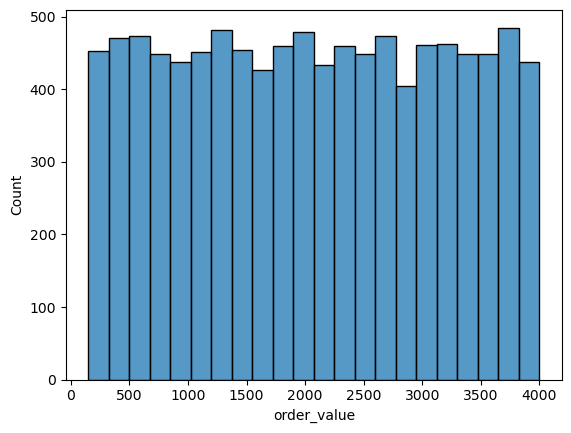

In [29]:
# 1. Order Value Distribution
sns.histplot(data=orders["order_value"],bins='auto')

### Insights
- The order value distribution appears relatively uniform across the price range, with no dominant peak.
- High-value orders (₹3500+) exist consistently but do not dominate the distribution.
- Customers appear to purchase across a wide range of price points, suggesting a balanced mix of budget and premium products rather than a price-sensitive customer base.
- Order values are fairly evenly distributed across price ranges, indicating a diverse purchasing behavior with consistent demand for both low and high-value products.

<Axes: xlabel='product_category', ylabel='order_value'>

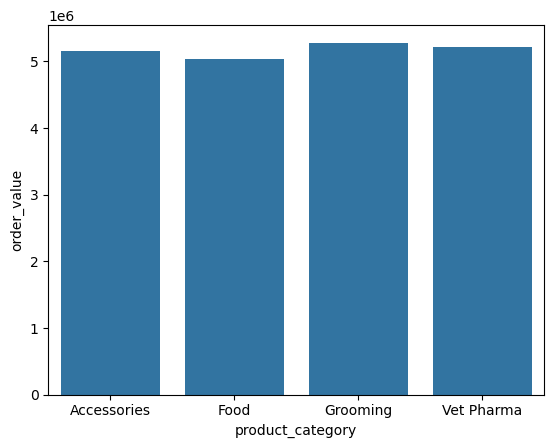

In [31]:
# 2 .Category-wise Revenue 
revenue = orders.groupby('product_category')['order_value'].sum()
revenue_df = revenue.reset_index()
sns.barplot(
    data=revenue_df,
    x="product_category",
    y="order_value"
)


### Insights
- Grooming emerges as the highest revenue-generating category, while Food contributes the lowest overall revenue.
- Revenue distribution across categories is relatively uniform, indicating balanced demand rather than reliance on a single category.
- Accessories and Vet Pharma show nearly equal revenue contribution, suggesting similar purchasing importance within the product mix.
- This balance may indicate cross-category purchasing behavior or a well-diversified catalog, which can be explored further through basket or order-level analysis.

<Axes: xlabel='city', ylabel='order_value'>

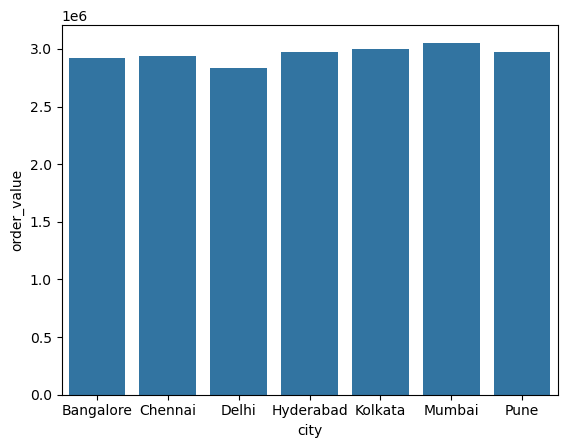

In [33]:
# 3 - City-level performance
cities = orders.groupby("city")['order_value'].sum()
city_df = cities.reset_index()
sns.barplot(
    data = city_df,
    x='city',
    y='order_value'
    )


### Insights
- City-wise revenue distribution is relatively uniform, indicating balanced performance across major cities rather than over-dependence on a single location.

- Mumbai emerges as the highest revenue-contributing city, while Delhi contributes the least among the listed cities.

- All cities generate significant revenue (above ~₹2.5M), suggesting strong market presence and demand consistency across geographies.

<Axes: xlabel='payment_mode', ylabel='order_value'>

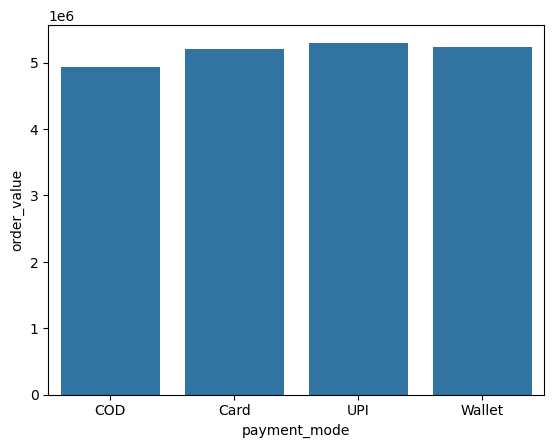

In [35]:
# 4 - Payment mode breakdown
Payment = orders.groupby("payment_mode")["order_value"].sum()
payment_df = Payment.reset_index()
sns.barplot(
    data = payment_df,
    x='payment_mode',
    y='order_value'
    )

### Insights
- UPI emerges as the highest revenue-generating payment mode, indicating strong adoption of digital payments.
- Cash on Delivery (COD) contributes the lowest revenue among the payment options, though it still represents a meaningful share.
- Card, UPI, and Wallet payments each generate revenues exceeding ₹5M, highlighting customer preference toward non-cash payment methods.
- Overall, revenue is skewed toward digital payment modes, suggesting that customers are increasingly comfortable completing purchases without cash.

<Axes: xlabel='delivery_tat', ylabel='Count'>

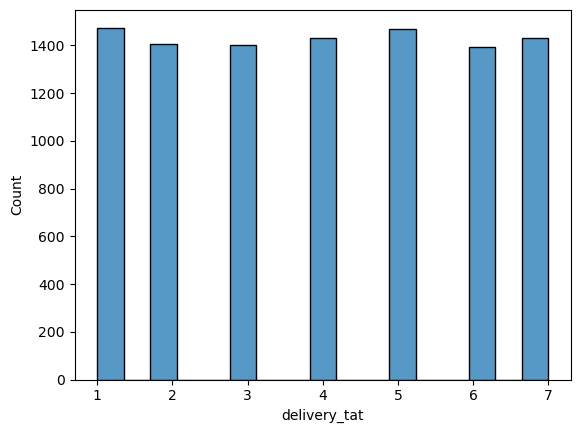

In [37]:
# 5 - Delivery TAT distribution
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["actual_delivery_date"] = pd.to_datetime(orders["actual_delivery_date"])
orders["delivery_tat"] = (orders["actual_delivery_date"] - orders["order_date"]).dt.days
sns.histplot(data=orders["delivery_tat"],bins='auto')	

### Insights
- Delivery TAT ranges from 1 to 7 days, with orders distributed fairly evenly across this range.
- The uniform distribution suggests consistent delivery performance, without heavy clustering at extreme delays.
- There is no significant long tail, indicating that severe delivery delays are not prevalent in the dataset.
- Overall, delivery timelines appear stable, which is favorable for customer experience.

<Axes: xlabel='channel', ylabel='click_rate'>

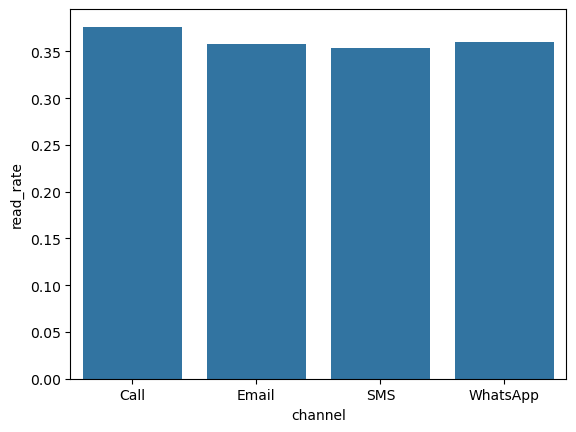

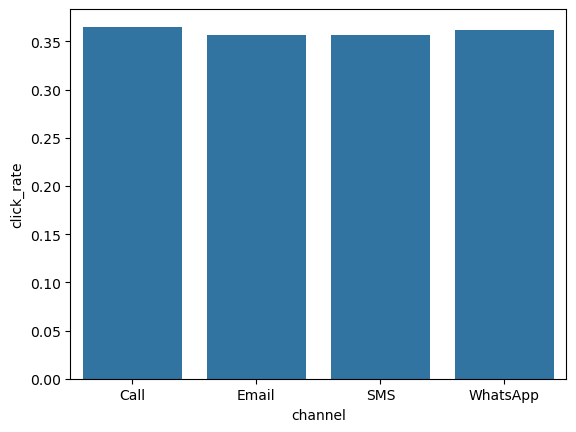

In [39]:
# 6 - Communication channel read/click effectiveness
communication_logs["read_true"] = communication_logs["delivery_status"] == "Read"
communication_logs["clicked_true"] =  communication_logs["customer_action"] == "Clicked" 
communication_logs["delivered_true"] =  communication_logs["delivery_status"] == "Delivered" 

read = communication_logs.groupby("channel")["read_true"].sum()
clicked = communication_logs.groupby("channel")["clicked_true"].sum()
delivered =  communication_logs.groupby("channel")["delivered_true"].sum()

communication_rate  = pd.DataFrame({
    "delivered": delivered,
    "read": read,
    "clicked": clicked
})

communication_rate["read_rate"] =communication_rate["read"] / communication_rate["delivered"]
communication_rate['click_rate'] = communication_rate["clicked"] / communication_rate["delivered"]

plt.figure()
sns.barplot(data=communication_rate, x="channel", y="read_rate")

plt.figure()
sns.barplot(data=communication_rate, x="channel", y="click_rate")


### Insights of read rate
- Read rates are broadly uniform across all channels, indicating consistent message visibility.
- Call shows a marginally higher read rate compared to other channels, though the difference is not significant.
- SMS exhibits the lowest read rate, suggesting slightly lower visibility or engagement.

### Insights of click rate
- Click rates are evenly distributed across channels, with no strong outliers.
- Call and WhatsApp show marginally higher click-through rates.
- The narrow spread in click rates suggests similar engagement effectiveness across channels.

<Axes: xlabel='week', ylabel='ticket_id'>

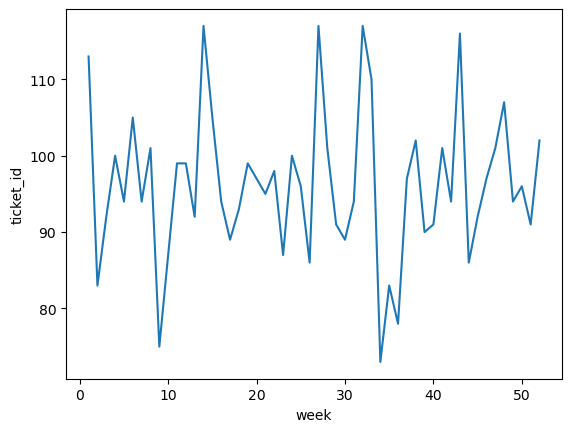

In [41]:
#  7 - Support ticket trend by week
support_tickets["week"] = pd.to_datetime(support_tickets["created_at"])
support_tickets["week"]  = support_tickets["week"].dt.isocalendar().week

by_week = support_tickets.groupby("week")["ticket_id"].count()
by_week = by_week.reset_index()
plt.figure()
sns.lineplot(data=by_week, x='week', y='ticket_id')


### Insights 
- Support ticket volume remains relatively stable across weeks, with normal week-to-week fluctuations.
- Several isolated peaks are observed (e.g., weeks ~1, ~14, ~28, ~31, ~42), indicating temporary increases in support demand.
- A noticeable dip around week ~32 suggests a short period of reduced ticket volume.


---

# B3. RFM & Customer Segmentation

In [44]:
reference_day = max(orders["order_date"]) + pd.Timedelta(days=1)

# Recency
customer_orders = orders.groupby("customer_id")["order_date"].max()
recency = recency = (reference_day - customer_orders).dt.days 

# Frequency
frequency = orders.groupby("customer_id")["order_id"].count()

# Monetory 
monetary = orders.groupby("customer_id")["order_value"].sum()

RFM = pd.DataFrame({
    'recency':recency,
    'frequency':frequency,
    'monetary':monetary
})

RFM['F_score'] = pd.qcut(
    RFM['frequency'],
    q=5,
    duplicates='drop'
)

RFM['M_score'] = pd.qcut(
    RFM['monetary'],
    q=5,
    duplicates='drop'
)

RFM['R_score'] = pd.qcut(
    RFM['recency'],
    q=5,
    duplicates='drop'
)

RFM['F_score'] = RFM['F_score'].cat.codes + 1
RFM['M_score'] = RFM['M_score'].cat.codes + 1
RFM['R_score'] = RFM['R_score'].cat.codes + 1

RFM['R_score'] = RFM['R_score'].max() + 1 - RFM['R_score']

RFM[['R_score', 'F_score', 'M_score']] = RFM[['R_score', 'F_score', 'M_score']].astype(int)
RFM['RFM_score'] = RFM['R_score'] + RFM['F_score'] + RFM['M_score']



In [45]:
RFM['segment'] = 'Bronze'  # default

RFM.loc[RFM['RFM_score'] >= 12, 'segment'] = 'Gold'
RFM.loc[(RFM['RFM_score'] >= 9) & (RFM['RFM_score'] <= 11), 'segment'] = 'Silver'

RFM.loc[
    (RFM['R_score'] <= 2) & (RFM['F_score'] >= 3),
    'segment'
] = 'At-Risk'

RFM.loc[
    (RFM['R_score'] >= 4) & (RFM['F_score'] == 1),
    'segment'
] = 'New'
RFM['segment'].value_counts()
RFM

,recency,frequency,monetary,F_score,M_score,R_score,RFM_score,segment
customer_id,,,,,,,,
1001,22,3,9499.65,2,5,5,12,Gold
1002,67,2,5728.43,1,5,4,10,New
1004,178,2,3338.67,1,3,2,6,Bronze
1005,318,1,2274.95,1,2,1,4,Bronze
1006,161,1,1623.44,1,2,3,6,Bronze
...,...,...,...,...,...,...,...,...
9994,273,1,2506.65,1,2,1,4,Bronze
9995,101,2,7286.33,1,5,4,10,New
9996,198,3,8731.35,2,5,2,9,Silver


<Axes: xlabel='segment', ylabel='monetary'>

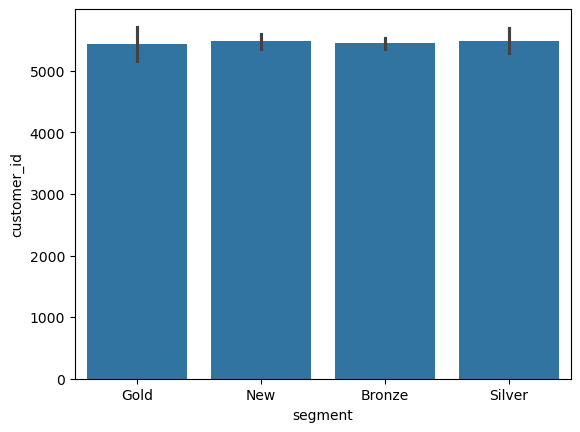

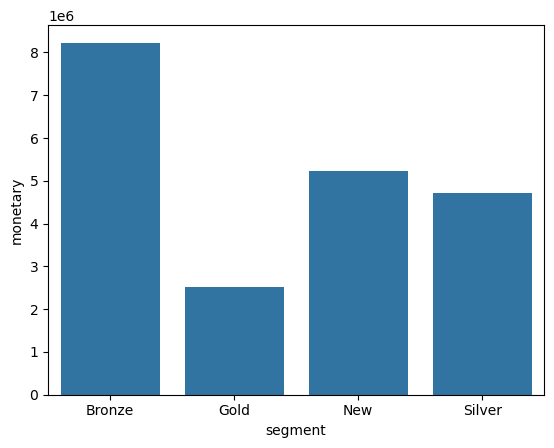

In [46]:
plt.figure()
sns.barplot(data=RFM ,x ='segment', y='customer_id')

mon = RFM.groupby('segment')['monetary'].sum()
mon = mon.reset_index()
plt.figure()
sns.barplot(data=mon ,x ='segment', y='monetary')

## 1️⃣ Customer Count by RFM Segment — Insights

### Key Observations
- **Bronze** is the largest segment, indicating most customers have low engagement or low value.
- **New customers** make up a significant portion, showing steady customer acquisition.
- **Silver** customers are fewer, representing a smaller group of moderately loyal customers.
- **Gold** customers are the smallest segment, which is typical for most e-commerce businesses.

### Business Interpretation
- The customer base is concentrated at the lower end of engagement.
- There is strong potential to nurture **Bronze** and **New** customers into **Silver** through retention campaigns.
- **Gold** customers are scarce and should be carefully retained due to their strategic importance.

---

## 2️⃣ Revenue Contribution by RFM Segment — Insights

### Key Observations
- **Bronze** customers generate the highest total revenue, mainly because of their large population.
- **Silver** and **New** segments contribute substantial revenue despite having fewer customers than Bronze.
- **Gold** customers contribute the lowest total revenue, primarily due to their small count.

### Important Nuance (Senior Insight)
- Lower total revenue from **Gold** customers does **not** mean they are low value.
- Their **average revenue per customer** is likely the highest, but their population is small.
- **Bronze** dominates total revenue due to volume, not individual customer value.


---

# Predictive Analysis

In [88]:
# =========================
# B4: Predictive Analytics
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression

# -------------------------------------------------
# 1. Target variable: did customer raise a ticket?
# -------------------------------------------------
ticket_flag = (
    support_tickets.groupby("customer_id")["ticket_id"]
    .count()
    .reset_index()
    .rename(columns={"ticket_id": "ticket_count"})
)

ticket_flag["raised_ticket"] = (ticket_flag["ticket_count"] > 0).astype(int)

# -------------------------------------------------
# 2. Aggregate order-level features to customer level
# -------------------------------------------------
orders_agg = orders.groupby("customer_id").agg({
    "order_value": "mean",
    "is_repeat_customer": "max",
    "shipment_mode": lambda x: x.mode()[0],
    "city": lambda x: x.mode()[0]
}).reset_index()

# -------------------------------------------------
# 3. Communication engagement features
# (join with orders to get customer_id)
# -------------------------------------------------
comm = communication_logs.merge(
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

comm["clicked"] = (comm["customer_action"] == "Clicked").astype(int)
comm["replied"] = (comm["customer_action"] == "Replied").astype(int)

comm_agg = comm.groupby("customer_id").agg({
    "clicked": "mean",
    "replied": "mean"
}).reset_index()

# -------------------------------------------------
# 4. Merge all features
# -------------------------------------------------
df = orders_agg.merge(comm_agg, on="customer_id", how="left")
df = df.merge(ticket_flag[["customer_id", "raised_ticket"]], on="customer_id", how="left")

df.fillna(0, inplace=True)

# -------------------------------------------------
# 5. Feature / target split
# -------------------------------------------------
X = df.drop(columns=["customer_id", "raised_ticket"])
y = df["raised_ticket"]

categorical_cols = ["city", "shipment_mode"]
numerical_cols = ["order_value", "is_repeat_customer", "clicked", "replied"]

# -------------------------------------------------
# 6. Preprocessing + model pipeline
# -------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# -------------------------------------------------
# 7. Train / test split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# -------------------------------------------------
# 8. Train model
# -------------------------------------------------
model.fit(X_train, y_train)

# -------------------------------------------------
# 9. Evaluation
# -------------------------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1 Score :", round(f1_score(y_test, y_pred), 3))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob), 3))


Accuracy : 0.56
Recall   : 0.637
F1 Score : 0.605
ROC AUC  : 0.571
